![FaMAF-UNC](https://drive.google.com/uc?export=download&id=1k4tzcXOoq6TrkDEW_Ox8o4Y4pAHzKHb7
)
> Docentes: **Damián Fernández** y **Leandro Milne**
>> Teórico del 05-05-2021


# Curvas y superficies

## Curvas

La clase pasada vimos que dada una trayectoria $\gamma:[a,b] \to \mathbb{R}^3$, para cada $t$ podemos definir en el punto $\gamma(t)$ de la curva un sistema coordenado dado por los vectores unitarios tangente, normal y binormal:
\begin{align*}
 T(t) &= \frac{\gamma'(t)}{\| \gamma'(t)\|},\\
 N(t) &= \frac{T'(t)}{\| T'(t)\|},\\
 B(t) &= T(t) \times N(t).
\end{align*}


#### Ejemplo

Considere $\gamma:[-\pi, \pi] \to \mathbb{R}^3$ tal que $\gamma(t) = \bigl( \cos(t), \operatorname{sen}(t), t \bigr)$.

Como $\gamma'(t) = \bigl( -\operatorname{sen}(t), \cos(t), 1 \bigr)$, entonces
$$
    T(t) = \frac{\gamma'(t)}{\| \gamma'(t)\|} = \frac{1}{\sqrt{2}} \bigl( -\operatorname{sen}(t), \cos(t), 1 \bigr).
$$
Ahora, como $T'(t) = \bigl( -\cos(t), -\operatorname{sen}(t), 0 \bigr)/\sqrt{2}$, se tiene
$$
    N(t) = \frac{T'(t)}{\| T'(t) \|} = \bigl( -\cos(t), -\operatorname{sen}(t), 0 \bigr).
$$
Luego,
$$
    B(t) = T(t) \times N(t) = \frac{1}{\sqrt{2}} \bigl( \operatorname{sen}(t), -\cos(t), 1\bigr).
$$


In [ ]:
#@title Marco de Frenet-Serret { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.animation as animation

from matplotlib import rc
rc('animation', html='jshtml')

t = np.linspace(-np.pi, np.pi, 200)
cos = np.cos(t)
sen = np.sin(t)

fig = plt.figure()
ax = fig.add_subplot(1,1,1,projection='3d')
plt.close()

def animacion(i):
  ax.clear()
#i = 95
  # ejes
  ax.plot3D([0,0],[-3,3], [0,0], color=(0.5,0.5,0.5))
  ax.plot3D([-3,3], [0,0], [0,0], color=(0.5,0.5,0.5))
  ax.plot3D([0,0], [0,0], [-3,3], color=(0.5,0.5,0.5))
  # gamma
  ax.plot3D(cos, sen, t, color='b')
  ax.plot3D([cos[i]], [sen[i]], [t[i]], 'ro')
  # T
  ax.quiver(cos[i], sen[i], t[i], -sen[i]/np.sqrt(2), cos[i]/np.sqrt(2), 1/np.sqrt(2), color='k', arrow_length_ratio=0.1)
  ax.text3D(cos[i]-sen[i]/np.sqrt(2), sen[i]+cos[i]/np.sqrt(2), t[i]+1/np.sqrt(2), '$T$', color='k', verticalalignment='top', horizontalalignment='left')
  # N
  ax.quiver(cos[i], sen[i], t[i], -cos[i], -sen[i], 0, color='k', arrow_length_ratio=0.1)
  ax.text3D(0, 0, t[i], '$N$', color='k', verticalalignment='top', horizontalalignment='left')
  # B
  ax.quiver(cos[i], sen[i], t[i], sen[i]/np.sqrt(2), -cos[i]/np.sqrt(2), 1/np.sqrt(2), color='k', arrow_length_ratio=0.1)
  ax.text3D(cos[i]+sen[i]/np.sqrt(2), sen[i]-cos[i]/np.sqrt(2), t[i]+1/np.sqrt(2), '$B$', color='k', verticalalignment='top', horizontalalignment='left')
  plot = ax.set_title('Marco de Frenet-Serret$')
  return plot

anim = animation.FuncAnimation(fig, animacion, frames=range(0,200,5), repeat = False)

anim
#plt.savefig("ejm_frenet.pdf")

Suponga por un momento que $\gamma:[a,b] \to \mathbb{R}^n$ es una trayectoria poligonal, entonces la longitud de la curva es la suma de la longitud de cada segmento. Por ejemplo, si tenemos $p$ segmentos entonces la longitud de $\gamma$ es
$$
    \ell(\gamma) = \sum_{k=1}^p \|g(t_k) - g(t_{k-1})\|,
$$
donde $a=t_0 < t_1 < \ldots < t_p=b$.


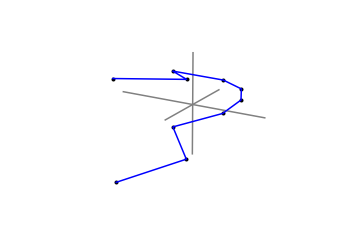

In [ ]:
#@title Curva poligonal { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

t = np.linspace(-3, 3, 10)
fig = plt.figure()
ax = fig.add_subplot(1,1,1,projection='3d')

# ejes
ax.plot3D([0,0],[-3,3], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([-3,3], [0,0], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([0,0], [0,0], [-3,3], color=(0.5,0.5,0.5))
# gamma
ax.plot3D(np.cos(t**2), 3-t**2, t, 'ko', markersize=3)
ax.plot3D(np.cos(t**2), 3-t**2, t, color='b')
ax.axis('off');
#plt.savefig("curvapoligonal.pdf")


Cuando la trayectoria es continuamente diferenciable a trozos, considere el límite de las poligonales sobre cualquier partición de $[a,b]$ con subintervalos tendientes a cero.

>**Definición**
>
> Si $\gamma:[a,b] \to \mathbb{R}^n$ es una trayectoria continuamente diferenciable a trozos, diremos que la **longitud** de $\gamma$ es
$$
\ell(\gamma) = \int_a^b  \| \gamma'(t) \| dt.
$$
Cuando $\ell(\gamma)<\infty$ se dice que $\gamma$ es una trayectoria **rectificable**.



Si tenemos una función de una variable $f:[a,b] \to \mathbb{R}$ y definimos $\gamma:[a,b] \to \mathbb{R}^2$ tal que $\gamma(t) = (t,f(t))$, de esta manera la curva de $\gamma$ coincide con el gráfico de $f$ y la longitud de dicha curva es
$$
    \ell(\gamma)=\int_a^b \sqrt{1+(f'(x))^2} dx,
$$
pues $\gamma'(t) = (1,f'(t))$.



Tome en cuenta que no toda curva es rectificable, un ejemplo de esto es la curva dada por $\gamma:[0,1] \to \mathbb{R}^2$ tal que
$$
\gamma(t) = \left\{\begin{array}{cc}
     \bigl( t, \operatorname{sen}(\pi/t)\bigr)& \textrm{ si } t\neq 0,\\
     (0,0) & \textrm{ si } t=0.
            \end{array}\right.
$$

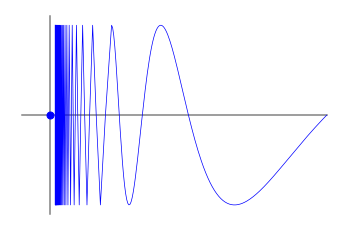

In [ ]:
#@title Trayectoria no rectificable { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

t1 = 2/np.arange(10,110)
t2 = np.linspace(2/9, 1, 200)
t = np.concatenate((np.flip(t1),t2))
fig, ax = plt.subplots()

# ejes
ax.plot([0,0],[-1.1,1.1], color=(0.5,0.5,0.5))
ax.plot([-0.1,1], [0,0], color=(0.5,0.5,0.5))
# gamma
ax.plot(t, np.sin(np.pi/t), color='b', linewidth=0.7)
ax.plot([0], [0], 'bo', markersize=7)
ax.axis('off');
#plt.savefig("norectificable.pdf")


Claramente, la longitud depende de la trayectoria que parametriza la curva.

#### Ejemplo

Considere dos parametrizaciones de  la circunferencia unitaria, $\gamma:[-1, 1] \to \mathbb{R}^2$ tal que $\gamma(t) = \bigl( \cos(\pi t), \operatorname{sen}(\pi t) \bigr)$ y $\sigma:[-1, 1] \to \mathbb{R}^2$ tal que $\sigma(t) = \bigl( \cos(2\pi(1-t^2)), \operatorname{sen}(2\pi(1-t^2)) \bigr)$. Como ya vimos, una recorre la circunferencia una vez y la otra dos veces. Ahora, usando que
    \begin{align*}
        \gamma'(t)&= \bigl( -\pi \operatorname{sen}(\pi t), \pi \cos(\pi t)\bigr),  \\
        \sigma'(t)&= \bigl( 4\pi t \operatorname{sen}(2\pi(1-t^2)), -4\pi t \cos(2\pi(1-t^2))\bigr),    
    \end{align*}
    obtenemos las siguientes longitudes
    \begin{align*}
        \ell(\gamma) &= \int_{-1}^1 \pi dt = 2\pi, \\
        \ell(\sigma) &= \int_{-1}^1 4\pi |t| dt = 2 \int_0^1 4\pi t dt = 4\pi.
    \end{align*}

---


En el ejemplo anterior una de las trayectorias recorre en el mismo tiempo el doble que la otra. Para analizar la velocidad con que una trayectoria rectificable $\gamma:[a,b] \to \mathbb{R}^n$ recorre una curva, se introduce la función de longitud de arco
$$
    \zeta(t) = \int_a^t \|\gamma'(u)\| du.
$$
Como $\zeta'(t) = \|\gamma'(t)\|$, se obtiene que
$$
    \ell(\gamma)=\int_a^b \zeta'(t) dt = \zeta(b) - \zeta(a) = \zeta(b).
$$
Si $\gamma'(t) \neq 0$ para todo $t\in [a,b]$, entonces $\zeta$ es una función creciente. Luego, es inyectiva y mapea el intervalo $[a,b]$ al $[0, \ell(\gamma)]$, con lo cual tiene una función inversa entre esos intervalos. Denotando por $\tau$ a su inversa, para $s\in [0, \ell(\gamma)]$ definimos
$$
    \sigma(s) = \gamma(\tau(s)).
$$
Como $s=\zeta(\tau(s))$, derivando se obtiene que $1 = \zeta'(\tau(s)) \tau'(s)  = \|\gamma'(\tau(s))\| \tau'(s) $. Por lo tanto $\tau'(s)=1/\|\gamma'(\tau(s))\|$ y
$$
    \sigma'(s) = \gamma'(\tau(s)) \tau'(s) = \frac{\gamma'(\tau(s))}{\| \gamma'(\tau(s))\|}.
$$
De esta manera $\|\sigma'(s)\|=1$ y $\ell(\sigma)=\int_0^{\ell(\gamma)} 1 ds = \ell(\gamma)$.
La trayectoria $\sigma$ se conoce como la **reparametrización por longitud de arco** de la curva dada por $\gamma$.



Note que $\sigma'(s) = T(\tau(s))$, donde $T$ es el vector tangente unitario. Derivando esta relación se obtiene que $\sigma''(s)=T'(\tau(s)) \tau'(s)$. Definiendo $\kappa(s) = \|\sigma''(s)\|$, y usando que $\tau'(s)>0$, se obtiene
$$
    \sigma''(s) = \kappa(s) \frac{T'(\tau(s))}{\|T'(\tau(s))\|} = \kappa(s) N(\tau(s)).
$$
El número $\kappa(s)$ nos dá la **curvatura** de la trayectoria en el punto $\sigma(s)$.



Ahora, toda trayectoria rectificable $\gamma:[a,b] \to \mathbb{R}^n$ puede escribirse como
$$
    \gamma(t) = \sigma(\zeta(t)),
$$
donde $\sigma$ es una trayectoria que recorre la curva con rapidez unitaria y $\zeta$ nos provee el avance de la partícula cuando $\gamma$ recorre la curva. Con esta descomposición, para la velocidad obtenemos
$$
    \gamma'(t) = \sigma'(\zeta(t)) \zeta'(t) = v(t) \sigma'(\zeta(t)) = v(t) T(t),
$$
donde usamos que $v(t) = \|\gamma'(t)\|= \zeta'(t)$ y $\tau(\zeta(t))=t$. Para la aceleración,
$$
    \gamma''(t) = v'(t) \sigma'(\zeta(t)) +  v(t) \zeta'(t) \sigma''(\zeta(t))
            = v'(t) T(t) + v(t)^2 \kappa(\zeta(t)) N(t).
$$
Obteniendo que la acelaración se descompone en una **componente tangencial** con magnitud $a_T(t)=v'(t)$ y una **componente normal** (o **centrípeta**) con magnitud $a_N(t)=v(t)^2 \kappa(\zeta(t))$.



#### Ejemplo

Suponga que se conoce la curva de un circuito de competición y deseamos recorrerlo en el menor tiempo posible y respetando el agarre del vehículo en las cuvas. Esto último vale si se respeta la elipse de fricción
$$
     \left(\frac{a_T(t)}{g \mu_T }\right)^2 + \left(\frac{a_N(t)}{g \mu_N }\right)^2 \leq 1,
$$
donde $g$ es la aceleración de la gravedad y $\mu_T$, $\mu_N$ las constantes de rozamiento tangencial y normal, respectivamente.
    
Haciendo una reparametrización por longitud de arco, obtenemos que el circuito viene dado por $\sigma:[0,1] \to \mathbb{R}^2$ y deseamos hallar el menor tiempo final $t_f$ y la función $\zeta:[0, t_f] \to [0,1]$ tal que
$$
        \gamma(t) = \sigma(\zeta(t)),
$$
sea la trayectoria óptima. Note que el domínio de $\zeta$ también es desconocido.
    
Para poder resolver este problema deberemos reescribirlo de una manera más conveniente. Utilizando $\tau:[0,1] \to [0,t_f]$, la inversa de $\zeta$, definamos $\nu(s) = v(\tau(s))$. Como $s=\zeta(\tau(s))$, derivando se tiene que
$$
   1 =  \zeta'(\tau(s)) \tau'(s) = v(\tau(s)) \tau'(s) = \nu(s) \tau'(s).
$$
Por lo tanto
$$
   \tau(s) = \tau(s)-\tau(0) = \int_0^s \tau'(u) du = \int_0^s \frac{1}{\nu(u)} du,
        \quad \textrm{y} \quad
       t_f = \tau(1) = \int_0^1 \frac{1}{\nu(s)} ds.
$$
Ahora deberemos también escribir la elipse de fricción en términos de la función  $\nu$. Como $\nu'(s) = v'(\tau(s)) \tau'(s)$, tenemos que
$$
    a_T(\tau(s)) = v'(\tau(s)) = \frac{\nu'(s)}{\tau'(s)} = \nu(s) \nu'(s)
            =\frac{1}{2} \frac{d (\nu^2)}{ds}(s).
$$
Definiendo $\alpha(s) = a_T(\tau(s))$, se obtiene la relación
$$
        \int_0^s \alpha(u) du = \frac{1}{2}(\nu(s)^2 - \nu(0)^2).
$$
De aquí, dando una velocidad inicial $\nu_0$ obtenemos que
$$
       \nu(s) = \sqrt{\nu_0^2 + 2\int_0^s \alpha(u) du},
$$
donde $\alpha$ es la aceleración tangencial y debe cumplir con la elipse de fricción. Como $a_N(\tau(s)) = v(\tau(s))^2 \kappa(s) = \nu(s)^2 \kappa(s)$, entonces
$$
        \frac{1}{(g \mu_T)^2} \alpha(s)^2 + \frac{\kappa(s)^2}{(g \mu_N)^2} \left( \nu_0^2 + 2\int_0^s \alpha(u) du \right)^2 \leq 1.
$$
    
    
De esta manera, nuestro problema es hallar $\nu_0 \in \mathbb{R}$ y una función $\alpha:[0,1] \to \mathbb{R}$ que cumplan con la desigualdad anterior y minimicen
$$
        \int_0^1 \left( \nu_0^2 + 2\int_0^s \alpha(u) du \right)^{-1/2} ds.
$$
    
Luego de conocidos $\nu_0$ y $\alpha$ óptimos, podemos definir el tiempo óptimo $t_f$ y la función $\tau$, de esta última obtenemos su inversa $\zeta$. Logrando de esta manera calcular la trayectoria óptima $\gamma:[0,t_f] \to \mathbb{R}^2$

---

## Superficies

Veamos ahora como entender la noción de derivada sobre una superficie. Para ello formalicemos la noción de superficie.

>**Definición**
>
> Diremos que $S\subset \mathbb{R}^3$ es una **superficie** si para cada $p\in S$ existe un abierto $V\subset \mathbb{R}^3$ con $p\in V$, un abierto $U\subset \mathbb{R}^2$ y una función $\phi: U \to V\cap S$ continua, inyectiva y sobreyectiva.
>
> Si además $\phi$ es continuamente diferenciable y $\phi'(x)$ tiene columnas linealmente independientes para todo $x\in U$, diremos que la superficie es **regular**.



Por lo tanto, $V\cap S$ es el conjunto definido paramétricamente por $\phi$.

Como se puede apreciar la definición es local y para cubrir la totalidad de una superficie quizás se necesiten varias parametrizaciones locales. Cada una de esas parametrizaciones cuyas imágenes cubren $S$, son llamadas **cartas** y la colección de ellas es llamada un **atlas**.


Note que si para un punto $\bar{x}$ definimos las trayectorias
$$
\gamma_1(t) = \phi(t,\bar{x}_2), \qquad \gamma_2(t) = \phi(\bar{x}_1,t),
$$
entonces las curvas dadas por estas trayectorias están contenidas en la superficie $S$. Además
$$
\gamma_1'(\bar{x}_1) = \frac{\partial \phi}{\partial x_1}(\bar{x})
    \quad \textrm{ y } \quad
\gamma_2'(\bar{x}_2) = \frac{\partial \phi}{\partial x_2}(\bar{x}),
$$
son vectores tangentes a $S$ en $\bar{p}=\phi(\bar{x})$. Si además estos vectores son linealmente independientes, podremos generar un plano tangente a $S$ en $\bar{p}$.
Como ya vimos, estos vectores son justamente las columnas de la matriz Jacobiana $\phi'(\bar{x})$.


#### Ejemplo

Veamos que $S=\{x\in\mathbb{R}^3 \mid \|x\|=1\}$ es una superficie regular. Definamos
$$
    \phi_1(x) = \left( x_1, x_2, \sqrt{1-(x_1^2 +x_2^2) } \right),
    \quad \operatorname{dom}(\phi_1)=B_1(0).
$$
Claramente $\operatorname{img}(\phi_1)$ es el hemisferio norte de la esfera. Además, como
$$
\frac{\partial \phi_1}{\partial x_1}(x) = \left(1, 0, \frac{-x_1}{\sqrt{1-(x_1^2 +x_2^2) }} \right)\quad \textrm{y} \quad
\frac{\partial \phi_1}{\partial x_2}(x) = \left(0, 1, \frac{-x_2}{\sqrt{1-(x_1^2 +x_2^2)} } \right),
$$
son continuas y linealmente independientes para todo $x\in B_1(0)$, tenemos lo requerido.


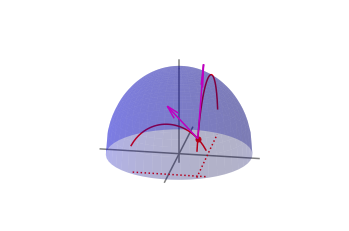

In [ ]:
#@title Esfera parametrizada { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

t = np.linspace(-3, 3, 10)
fig = plt.figure()
ax = fig.add_subplot(1,1,1,projection='3d')

# ejes
ax.plot3D([0,0],[-1.1,1.1], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([-1.1,1.1], [0,0], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([0,0], [0,0], [-0.1,1.1], color=(0.5,0.5,0.5))
# grilla
th = np.linspace(0, 2*np.pi, 50)
r = np.linspace(0, 1, 30)
x = np.outer(r, np.cos(th))
y = np.outer(r, np.sin(th))
z = np.outer(np.sqrt(1-r**2), np.ones(th.shape))
# casquete
ax.plot_surface(x, y, z, color='b', alpha=0.3)
# punto
i = 26
j = 28
p = np.array([x[i,j], y[i,j], z[i,j]])
ax.plot3D([p[0]],[p[1]], [p[2]], 'ro', markersize=5)
# curvas
t1 = np.linspace(-np.sqrt(0.9-p[1]**2), np.sqrt(0.9-p[1]**2),30)
ax.plot3D(t1, p[1]*np.ones(t1.shape), np.sqrt(1-t1**2-p[1]**2), 'r')
ax.plot3D(t1, p[1]*np.ones(t1.shape), np.zeros(t1.shape), 'r:')
t2 = np.linspace(-np.sqrt(0.9-p[0]**2), np.sqrt(0.9-p[0]**2),30)
ax.plot3D(p[0]*np.ones(t1.shape), t2, np.sqrt(1-p[0]**2-t2**2), 'r')
ax.plot3D(p[0]*np.ones(t1.shape), t2, np.zeros(t2.shape), 'r:')

tan1 = np.array([1,0,-p[0]/p[2]])
ax.quiver(p[0], p[1], p[2], tan1[0], tan1[1], tan1[2], length=0.4, color='m')
tan2 = np.array([0,1,-p[1]/p[2]])
ax.quiver(p[0], p[1], p[2], tan2[0], tan2[1], tan2[2], length=0.4, color='m')
ax.view_init(30,190)
ax.axis('off');
#plt.savefig("ejm_carta.pdf")


Para cubir el hemisferio sur de la esfera, definimos
$$
    \phi_2(x) = \left( x_1, x_2, -\sqrt{1-(x_1^2 +x_2^2) } \right),
    \quad \operatorname{dom}(\phi_2)=B_1(0).
$$
Juntando las imágenes de $\phi_1$ y $\phi_2$ tendremos cubierta la esfera sin el ecuador. Para cubrirla totalmente deberemos definir las siguientes funciones con dominio en $B_1(0)$,
\begin{align*}
    \phi_3(x) &= \left( x_1, \sqrt{1-(x_1^2 +x_2^2) }, x_2  \right),\\
    \phi_4(x) &= \left( x_1, -\sqrt{1-(x_1^2 +x_2^2) }, x_2  \right),\\
    \phi_5(x) &= \left( \sqrt{1-(x_1^2 +x_2^2) }, x_1, x_2  \right),\\
    \phi_6(x) &= \left( -\sqrt{1-(x_1^2 +x_2^2) }, x_1, x_2  \right).
\end{align*}
De esta manera, la esfera es una superficie regular y pudimos cubrirla con un atlas de seis cartas.

---
---

<a href="https://www.youtube.com/channel/UCnW0Y4oaWxMwNZzV4UjgnPw/featured" target="_blank">Canal de Youtube</a>

<img src="https://asamaci.org.ar/wp-content/uploads/2020/10/LOGO_MACI.png" alt="MACI 2021" width="500">

